# 06 — Baselines (Phase 3)

**No model is trained in this notebook.** That is the point of it.

A PR-AUC of 0.42 at a base rate of 1-in-1,291 sounds excellent. Whether it *is*
excellent depends entirely on what you get from doing something trivial, and
"something trivial" does better here than most people expect: flood depth barely
changes in 15 minutes, so simply repeating the current reading already predicts
most of the next hour correctly.

Recording the bar **before** training means every later number arrives with
something honest beside it. Recording it afterwards means choosing which
baseline to publish once you have seen how the model did, which is not the same
activity even when done with the best intentions.

### The four baselines

| Baseline | What it does | Why it is here |
|---|---|---|
| **persistence** | "it will be as it is now" | nearly unbeatable on already-flooded rows |
| **climatology** | how often has *this station, this hour, this month* flooded | tests whether flooding is just a schedule |
| **rain_rule** | alert when district rainfall crosses a threshold | closest to what BMA can do today — the bar that actually matters |
| **always_negative** | predicts nothing, ever | scores 99.92% accuracy, which is why accuracy appears nowhere in this project |

### What you need to run

`05_features.ipynb` must have been run. This notebook takes about 4 minutes and
trains nothing.

## Setup

In [1]:
import os, sys, json, time
from pathlib import Path

_here = Path.cwd()
_root = next(p for p in [_here, *_here.parents] if (p / "config/config.yaml").is_file())
sys.path.insert(0, str(_root / "src"))
os.chdir(_root)

import numpy as np
import pandas as pd
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 80)

from bkkflood.config import load_config
from bkkflood.rawio import connect
CFG = load_config()

# config lists years as [first, last]; expand it to every year in between.
_yrs = CFG["data"]["years"]
YEARS = list(range(_yrs[0], _yrs[-1] + 1)) if len(_yrs) == 2 else list(_yrs)

print("years:", YEARS, "| horizons:", CFG["horizons_hours"],
      "| tiers:", CFG["flood_event"]["tiers_cm"])

years: [2019, 2020, 2021, 2022, 2023, 2024, 2025] | horizons: [1, 3, 6] | tiers: {'nuisance': 5, 'advisory': 15, 'severe': 30}


## 1. The splits

**Chronological, never shuffled.** Consecutive readings five minutes apart are
nearly identical. A random split scatters near-copies of the test rows into
training, which inflates every score by 20–30 points and cannot be reproduced in
production — the model would be predicting the past from the future.

Each fold trains on earlier years, tunes on the next one, and is tested on the
one after that. The validation year exists so that **decision thresholds are
chosen without ever seeing the test year**. Tuning a threshold on the test set is
not leakage of data but leakage of the *decision*, and it is quietly worth
several points.

In [2]:
from bkkflood.evaluate import folds

FOLDS = folds()
print(pd.DataFrame(FOLDS).to_string(index=False))
print(f"\nembargo at each boundary: {CFG['splits']['embargo_hours']} hours")
print("(features look back 24 h, so a row on 1 January contains readings from")
print(" 31 December — the last day of training is dropped, never the test data)")

                         train  val  test
                  [2019, 2020] 2021  2022
            [2019, 2020, 2021] 2022  2023
      [2019, 2020, 2021, 2022] 2023  2024
[2019, 2020, 2021, 2022, 2023] 2024  2025

embargo at each boundary: 24 hours
(features look back 24 h, so a row on 1 January contains readings from
 31 December — the last day of training is dropped, never the test data)


## 2. Run every baseline

Across every fold, every depth tier and every horizon. Only the columns each
baseline needs are read: a year is 3.5 million rows by 79 columns, and this
project has already been killed by the operating system once for loading two
years at full width.

In [3]:
from bkkflood.features import load_features
from bkkflood.baselines import run_baselines

TIERS = sorted(int(t) for t in CFG["flood_event"]["tiers_cm"].values())
HORIZONS = CFG["horizons_hours"]
NEEDED = ["fl_depth_now", "rain_rf1hr_mean"]

con = connect()
results = []
for fold in FOLDS:
    for tier in TIERS:
        for h in HORIZONS:
            va = load_features([fold["val"]], NEEDED, tier_cm=tier, horizon_h=h, con=con)
            te = load_features([fold["test"]], NEEDED, tier_cm=tier, horizon_h=h, con=con)
            r = run_baselines(fold["train"], te, tier_cm=tier,
                              horizon_h=h, threshold_source=va, con=con)
            r["fold_test_year"] = fold["test"]
            r["train_years"] = str(fold["train"])
            results.append(r)
            del va, te
    print(f"fold tested on {fold['test']} done")

BASE = pd.concat(results, ignore_index=True)
BASE.to_parquet("data/features/baseline_results.parquet", index=False)
print("\n", BASE.shape, "-> data/features/baseline_results.parquet")

fold tested on 2022 done
fold tested on 2023 done
fold tested on 2024 done
fold tested on 2025 done

 (144, 23) -> data/features/baseline_results.parquet


## 3. The headline table

The operational setting: **15 cm depth, 1 hour ahead**, averaged across folds.

In [4]:
def view(tier, h, cols=None):
    cols = cols or ["baseline", "pr_auc", "base_rate", "precision", "recall", "f2",
                    "fnr", "recall_onset", "recall_ongoing", "positives", "tp", "fp"]
    d = BASE[(BASE.tier_cm == tier) & (BASE.horizon_h == h)]
    return (d.groupby("baseline", sort=False)[[c for c in cols if c != "baseline"]]
             .mean().round(4).reset_index())

print("15 cm, 1 hour ahead — mean across folds")
print(view(15, 1).to_string(index=False))

15 cm, 1 hour ahead — mean across folds
       baseline  pr_auc  base_rate  precision  recall     f2    fnr  recall_onset  recall_ongoing  positives     tp       fp
    persistence  0.5529     0.0004     0.6175  0.5443 0.5541 0.4557        0.1635          1.0000    1264.25 749.25   400.00
    climatology  0.0009     0.0004     0.0019  0.1037 0.0085 0.8963        0.0952          0.1159    1264.25 140.00 73124.25
      rain_rule  0.1035     0.0004     0.1066  0.3154 0.2185 0.6846        0.2180          0.4425    1264.25 389.50  3054.00
always_negative  0.0004     0.0004     0.0000  0.0000 0.0000 1.0000        0.0000          0.0000    1264.25   0.00     0.00


### How to read this, in plain terms

**`fnr` is the miss rate.** It is `1 - recall`, written out so that nobody
reports 45% recall without also having said "we miss more than half of them".

**`pr_auc` has a floor of `base_rate`, not zero.** At roughly 1 positive in
1,300 rows, a PR-AUC of 0.10 is a hundredfold improvement over guessing. Quoting
it without the base rate beside it is meaningless in either direction.

**The two recall columns are the whole story.**

- `recall_ongoing` — the road was *already* flooded. Predicting it stays flooded
  is correct and nearly free.
- `recall_onset` — the road was *dry*. This is forecasting.

Persistence should show a large gap between them. That gap is the honest
statement of the problem: the easy half of the job is already solved by a
thermometer, and the half that is worth building a system for is the hard one.

In [5]:
head = view(15, 1).set_index("baseline")
p = head.loc["persistence"]
print(f"persistence, 15 cm / 1 h")
print(f"  overall recall  {p.recall:.1%}   <- what a single number would report")
print(f"  ongoing recall  {p.recall_ongoing:.1%}   <- the road was already flooded")
print(f"  ONSET recall    {p.recall_onset:.1%}   <- the road was dry: real forecasting")
print()
print(f"  and it raises {int(p.fp):,} false alarms to catch {int(p.tp):,} true ones")
print(f"  (precision {p.precision:.1%})")
print()
print("This is the bar. A model that beats persistence overall but not on the")
print("onset row has not beaten it at anything that matters.")

persistence, 15 cm / 1 h
  overall recall  54.4%   <- what a single number would report
  ongoing recall  100.0%   <- the road was already flooded
  ONSET recall    16.4%   <- the road was dry: real forecasting

  and it raises 400 false alarms to catch 749 true ones
  (precision 61.8%)

This is the bar. A model that beats persistence overall but not on the
onset row has not beaten it at anything that matters.


### The result that should shape Phase 4

Rank the baselines by **overall** score and persistence wins comfortably. Rank
them by **onset recall** — the dry roads — and the ordering can change.

That is not a curiosity. It says the two halves of this problem want different
inputs: the current depth reading answers "is this road wet *now*", and rainfall
answers "is this road *about to be*". A single model asked to optimise one
number will spend its capacity on the first question, because that is where the
rows are.

It is the empirical case for the onset specialist in Phase 4.

In [6]:
cmp = (BASE[(BASE.tier_cm == 15) & (BASE.horizon_h == 1)]
       .groupby("baseline")[["recall", "recall_onset", "precision", "pr_auc"]]
       .mean().sort_values("recall", ascending=False).round(4))
cmp["rank_overall"] = cmp.recall.rank(ascending=False).astype(int)
cmp["rank_onset"] = cmp.recall_onset.rank(ascending=False).astype(int)
print(cmp.to_string())

best_overall = cmp.recall.idxmax()
best_onset = cmp.recall_onset.idxmax()
print()
if best_overall != best_onset:
    print(f"Best overall recall : {best_overall}")
    print(f"Best ONSET recall   : {best_onset}   <- different baseline")
    print()
    print("The rows that need forecasting are best served by a different signal")
    print("than the rows that need monitoring. Phase 4 trains a separate onset")
    print("specialist for exactly this reason.")
else:
    print(f"{best_overall} leads on both. The onset gap is still the number to beat.")

                 recall  recall_onset  precision  pr_auc  rank_overall  rank_onset
baseline                                                                          
persistence      0.5443        0.1635     0.6175  0.5529             1           2
rain_rule        0.3154        0.2180     0.1066  0.1035             2           1
climatology      0.1037        0.0952     0.0019  0.0009             3           3
always_negative  0.0000        0.0000     0.0000  0.0004             4           4

Best overall recall : persistence
Best ONSET recall   : rain_rule   <- different baseline

The rows that need forecasting are best served by a different signal
than the rows that need monitoring. Phase 4 trains a separate onset
specialist for exactly this reason.


## 4. Does it get harder further out?

It must. If 6-hour scores match 1-hour scores, something is wrong — most likely
a feature that knows more than it should.

In [7]:
grid = (BASE[BASE.tier_cm == 15]
        .groupby(["baseline", "horizon_h"])[["pr_auc", "f2", "recall_onset", "fnr"]]
        .mean().round(4))
print(grid.to_string())
print()
pers = grid.loc["persistence"]
if pers.pr_auc.is_monotonic_decreasing:
    print("PR-AUC falls with horizon, as it must.")
else:
    print("WARNING: PR-AUC does not fall with horizon. Investigate before proceeding.")

                           pr_auc      f2  recall_onset     fnr
baseline        horizon_h                                      
always_negative 1          0.0004  0.0000        0.0000  1.0000
                3          0.0007  0.0000        0.0000  1.0000
                6          0.0012  0.0000        0.0000  1.0000
climatology     1          0.0009  0.0085        0.0952  0.8963
                3          0.0018  0.0157        0.1242  0.8748
                6          0.0030  0.0246        0.1150  0.8824
persistence     1          0.5529  0.5541        0.1635  0.4557
                3          0.2856  0.3182        0.0896  0.7003
                6          0.1682  0.1963        0.0472  0.8252
rain_rule       1          0.1035  0.2185        0.2180  0.6846
                3          0.0578  0.1488        0.1059  0.8084
                6          0.0356  0.1017        0.0659  0.8736

PR-AUC falls with horizon, as it must.


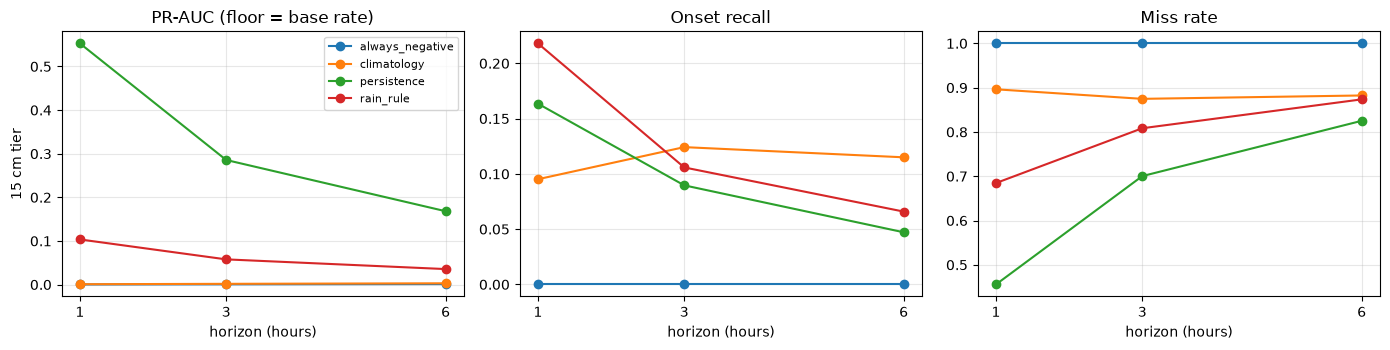

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, metric, title in zip(axes, ["pr_auc", "recall_onset", "fnr"],
                             ["PR-AUC (floor = base rate)", "Onset recall", "Miss rate"]):
    for name, g in BASE[BASE.tier_cm == 15].groupby("baseline"):
        m = g.groupby("horizon_h")[metric].mean()
        ax.plot(m.index, m.values, marker="o", label=name)
    ax.set_title(title); ax.set_xlabel("horizon (hours)")
    ax.set_xticks(HORIZONS); ax.grid(alpha=.3)
axes[0].set_ylabel("15 cm tier"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Events, not rows

A three-hour flood is twelve rows at 15-minute spacing. Catching the last eleven
looks like 92% recall and is a **failure** — the water was already there. Catching
the first one is the entire job.

So events are scored whole, and **lead time is always reported beside the hit
rate**. A flood detected five minutes before it arrives is detection; it is not
warning, and BMA cannot dispatch anyone on it.

In [9]:
from bkkflood.evaluate import event_pod
from bkkflood.baselines import persistence, climatology, apply_climatology, rain_rule
from bkkflood.evaluate import best_threshold

TIER, H = 15, 3
rows = []
for fold in FOLDS:
    va = load_features([fold["val"]], NEEDED, tier_cm=TIER, horizon_h=H, con=con)
    te = load_features([fold["test"]], NEEDED, tier_cm=TIER, horizon_h=H, con=con)
    te = te[te[f"y_valid_{H}h"].fillna(False)].copy()
    y_va = va.loc[va[f"y_valid_{H}h"].fillna(False), f"y_ge{TIER}_{H}h"].fillna(False)

    for name, fn in [("persistence", lambda d: persistence(d, TIER)),
                     ("rain_rule", rain_rule)]:
        thr = best_threshold(y_va.to_numpy(bool),
                             fn(va[va[f"y_valid_{H}h"].fillna(False)]), metric="f2")
        te["pred"] = np.nan_to_num(fn(te), nan=-np.inf) >= thr["threshold"]
        # Events come from the OBSERVED DEPTH crossing the tier -- the water
        # actually arriving -- not from runs of positive labels. A label run
        # begins up to h hours before the flood, so lead time measured against
        # it is lead against a bookkeeping artefact and is not comparable
        # between horizons.
        r = event_pod(te, "fl_depth_now", "pred", tier_cm=TIER, horizon_h=H)
        rows.append({"baseline": name, "test_year": fold["test"], **r})
    del va, te

EV = pd.DataFrame(rows)
print(f"Events at {TIER} cm, {H} h ahead\n")
print(EV.groupby("baseline")[["events", "events_detected", "event_pod",
                              "median_lead_minutes", "p25_lead_minutes"]]
        .mean().round(2).to_string())

Events at 15 cm, 3 h ahead

             events  events_detected  event_pod  median_lead_minutes  p25_lead_minutes
baseline                                                                              
persistence   143.0             1.75       0.01                150.0             125.0
rain_rule     143.0             2.00       0.01                142.5              97.5


**Event POD without lead time is not a claim about a warning system.** A
baseline can post a high detection rate while giving crews almost no notice —
that is a very different product from one that gives an hour, and the two must
never appear in a report as the same number.

## 6. Write it down

Recorded now, before any model exists, so nothing here can be revised in the
light of a result.

In [10]:
out = Path("docs/reports/baselines.md")
out.parent.mkdir(parents=True, exist_ok=True)
with out.open("w") as f:
    f.write("# Baselines — recorded before any model was trained\n\n")
    f.write("Generated by `notebooks/06_baselines.ipynb`.\n")
    f.write(f"Rolling-origin folds, {CFG['splits']['embargo_hours']} h embargo. ")
    f.write("Thresholds tuned on the validation year, never on the test year.\n\n")
    f.write("## The bar to beat: 15 cm, 1 hour ahead\n\n")
    f.write(view(15, 1).to_markdown(index=False))
    f.write("\n\n### Why the onset column is the one that counts\n\n")
    f.write(f"Persistence reaches {p.recall_ongoing:.0%} recall on rows where the road was\n")
    f.write(f"already flooded and {p.recall_onset:.0%} where it was dry. A single recall\n")
    f.write("number averages those into something that describes a monitor, not a\n")
    f.write("forecaster. Every model result must be reported the same way.\n\n")
    f.write("## All tiers and horizons\n\n")
    f.write(BASE.groupby(["tier_cm", "horizon_h", "baseline"])[
        ["pr_auc", "base_rate", "precision", "recall", "recall_onset", "f2", "fnr"]
    ].mean().round(4).to_markdown())
    f.write("\n\n## Events and lead time\n\n")
    f.write(EV.groupby("baseline")[["events", "events_detected", "event_pod",
                                    "median_lead_minutes"]].mean().round(2).to_markdown())
    f.write("\n\n## Promotion rule\n\n")
    f.write("A model is only worth deploying if it beats **persistence on onset recall\n")
    f.write("at the 15 cm tier**, at equal or better precision. Beating persistence on\n")
    f.write("overall recall means only that it has also learned to repeat the current\n")
    f.write("reading.\n")
print("wrote", out)

wrote docs/reports/baselines.md


## What Phase 3 produced

| | |
|---|---|
| `data/features/features_YYYY.parquet` | 7 years of model-ready rows |
| `data/features/baseline_results.parquet` | every baseline, fold, tier and horizon |
| `docs/reports/feature_contract.md` | what each column means and at what resolution |
| `docs/reports/baselines.md` | the bar, recorded before any model existed |

**The number to carry into Phase 4:** persistence's *onset* recall at 15 cm / 1 h.
That is what a model has to beat to be worth anything. Beating the overall figure
only proves it has learned to repeat the current sensor reading, which we can
already do for free.